# 1. Data Loader and Dataset EDA

Install requirements before running the notebooks:

```bash
pip install -r requirements.txt
```

This notebook prepares EuroSAT from KaggleHub when needed, then runs basic dataset EDA. If `data/eurosat/imagefolder` already exists, the download step is skipped.


In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.prepare_eurosat import download_eurosat_with_kagglehub, prepare_eurosat_imagefolder

dataset_dir = PROJECT_ROOT / "data" / "eurosat" / "imagefolder"
metadata_path = PROJECT_ROOT / "data" / "eurosat" / "split_metadata.json"

if dataset_dir.exists():
    metadata = prepare_eurosat_imagefolder(
        raw_dir=dataset_dir,
        output_dir=dataset_dir,
        metadata_path=metadata_path,
        seed=42,
        force=False,
    )
    print(f"Prepared EuroSAT split already exists: {dataset_dir}")
else:
    raw_dir = download_eurosat_with_kagglehub(cache_dir=PROJECT_ROOT / "data" / "kagglehub")
    metadata = prepare_eurosat_imagefolder(
        raw_dir=raw_dir,
        output_dir=dataset_dir,
        metadata_path=metadata_path,
        seed=42,
        force=False,
    )
metadata


Prepared EuroSAT split already exists: c:\Users\user\Documents\projects\oxfordflowers\FewShotEuroSAT\data\eurosat\imagefolder


{'dataset': 'eurosat',
 'source': 'waseemalastal/eurosat-rgb-dataset',
 'split': 'deterministic 70/20/10 per class',
 'seed': 42,
 'classes': {'Pasture': {'total': 2000,
   'train': 1400,
   'val': 400,
   'test': 200},
  'Residential': {'total': 3000, 'train': 2100, 'val': 600, 'test': 300},
  'Highway': {'total': 2500, 'train': 1750, 'val': 500, 'test': 250},
  'SeaLake': {'total': 3000, 'train': 2100, 'val': 600, 'test': 300},
  'Industrial': {'total': 2500, 'train': 1750, 'val': 500, 'test': 250},
  'HerbaceousVegetation': {'total': 3000,
   'train': 2100,
   'val': 600,
   'test': 300},
  'AnnualCrop': {'total': 3000, 'train': 2100, 'val': 600, 'test': 300},
  'PermanentCrop': {'total': 2500, 'train': 1750, 'val': 500, 'test': 250},
  'River': {'total': 2500, 'train': 1750, 'val': 500, 'test': 250},
  'Forest': {'total': 3000, 'train': 2100, 'val': 600, 'test': 300}}}

## Split Counts

In [5]:
import json
import pandas as pd

metadata_path = PROJECT_ROOT / "data" / "eurosat" / "split_metadata.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8-sig"))
rows = []
for class_name, split_counts in metadata["classes"].items():
    for split in ["train", "val", "test"]:
        rows.append({"class_name": class_name, "split": split, "count": split_counts[split]})
counts = pd.DataFrame(rows)
counts.pivot(index="class_name", columns="split", values="count")


split,test,train,val
class_name,,,
AnnualCrop,300,2100,600
Forest,300,2100,600
HerbaceousVegetation,300,2100,600
Highway,250,1750,500
Industrial,250,1750,500
Pasture,200,1400,400
PermanentCrop,250,1750,500
Residential,300,2100,600
River,250,1750,500


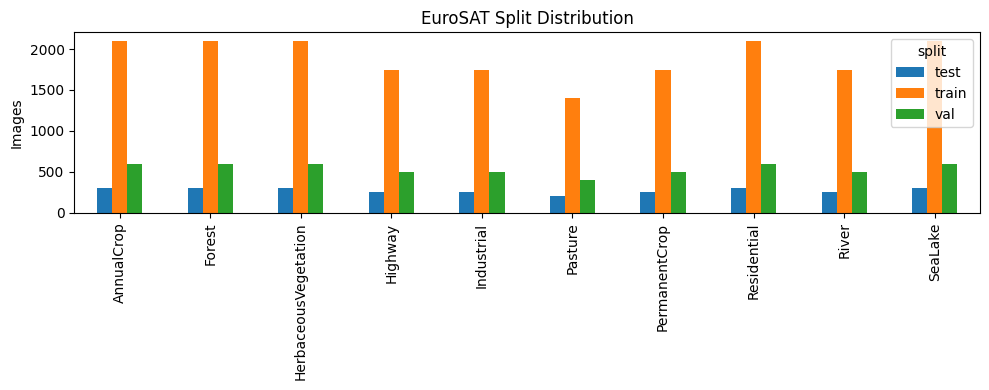

In [6]:
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

split_table = counts.pivot(index="class_name", columns="split", values="count")
ax = split_table.plot(kind="bar", figsize=(10, 4))
ax.set_xlabel("")
ax.set_ylabel("Images")
ax.set_title("EuroSAT Split Distribution")
plt.tight_layout()


## Representative Samples

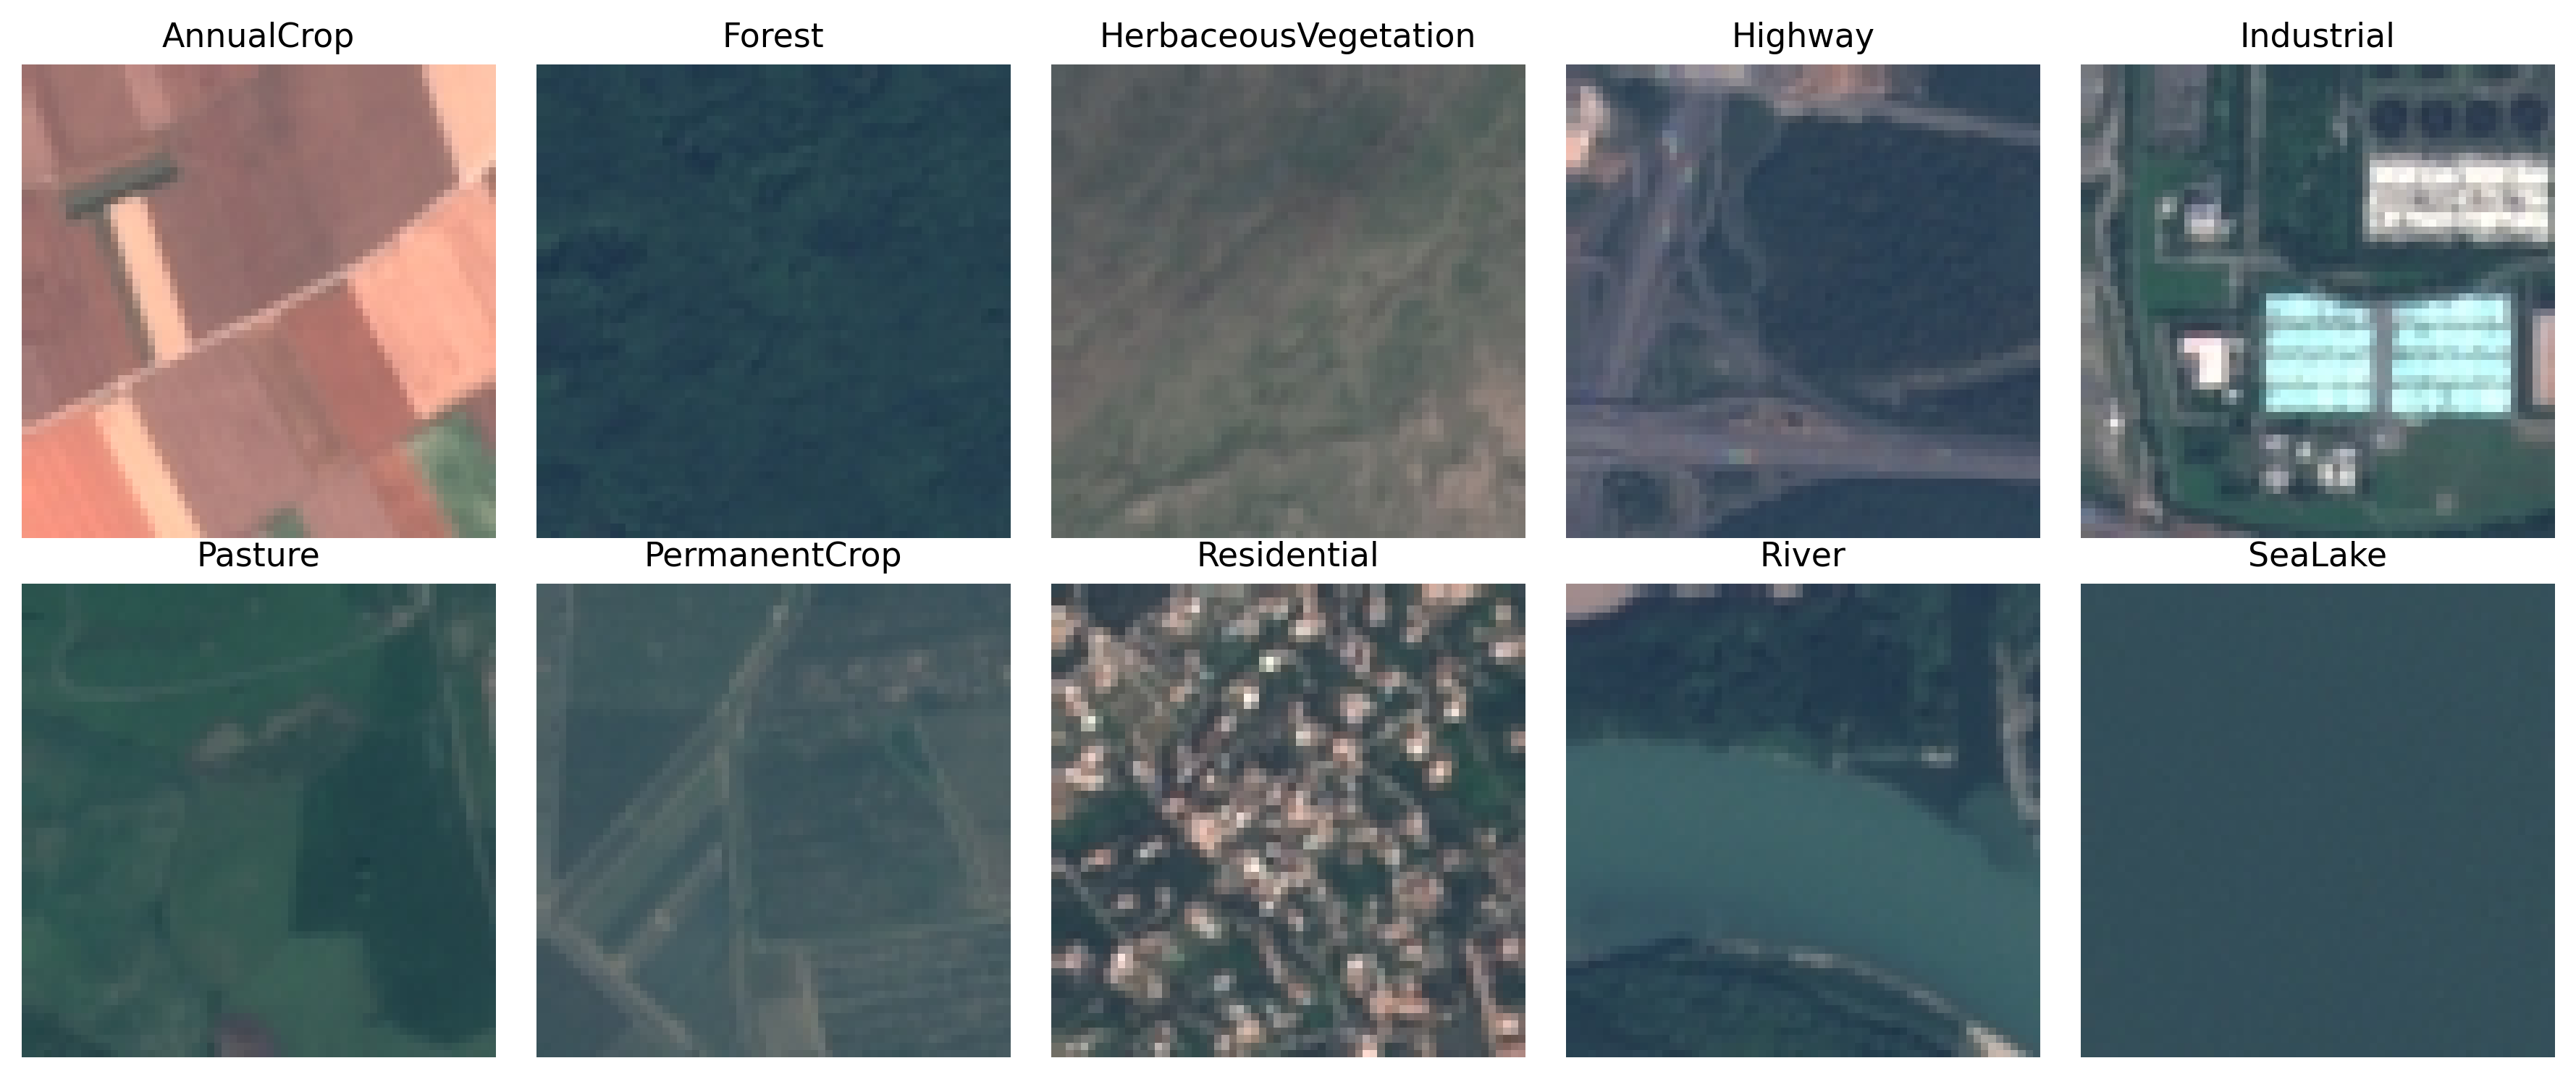

In [7]:
from IPython.display import Image, display
from src.dataset_visuals import eurosat_sample_grid

sample_path = eurosat_sample_grid(
    dataset_dir=PROJECT_ROOT / "data" / "eurosat" / "imagefolder",
    output=PROJECT_ROOT / "paper_assets" / "eurosat_samples.png",
    split="train",
    seed=42,
)
display(Image(filename=str(sample_path)))

## Image Shape Check

In [8]:
from PIL import Image as PILImage

image_paths = list((PROJECT_ROOT / "data" / "eurosat" / "imagefolder").glob("*/*/*"))
shape_rows = []
for path in image_paths[:1000]:
    with PILImage.open(path) as img:
        shape_rows.append({"width": img.width, "height": img.height, "mode": img.mode})
pd.DataFrame(shape_rows).value_counts().reset_index(name="count").head()

,width,height,mode,count
0,64,64,RGB,1000
